Gaussian Naïve Bayes Classifier on Iris Dataset
(i) Step-by-step Implementation
(ii) Built-in Function Implementation

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.naive_bayes import GaussianNB

In [28]:
iris = load_iris()
X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(y, iris.target_names)

print("Dataset shape:", df.shape)
print("\nFeature names:", iris.feature_names)
print("\nTarget names:", iris.target_names)
print("\nFirst few rows:")
print(df.head(10))
print("\nClass distribution:")
print(df['species'].value_counts())

Dataset shape: (150, 5)

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target names: ['setosa' 'versicolor' 'virginica']

First few rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   
5                5.4               3.9                1.7               0.4   
6                4.6               3.4                1.4               0.3   
7                5.0               3.4                1.5               0.2   
8                4.4               2.9                1.4               0.2   
9                4.

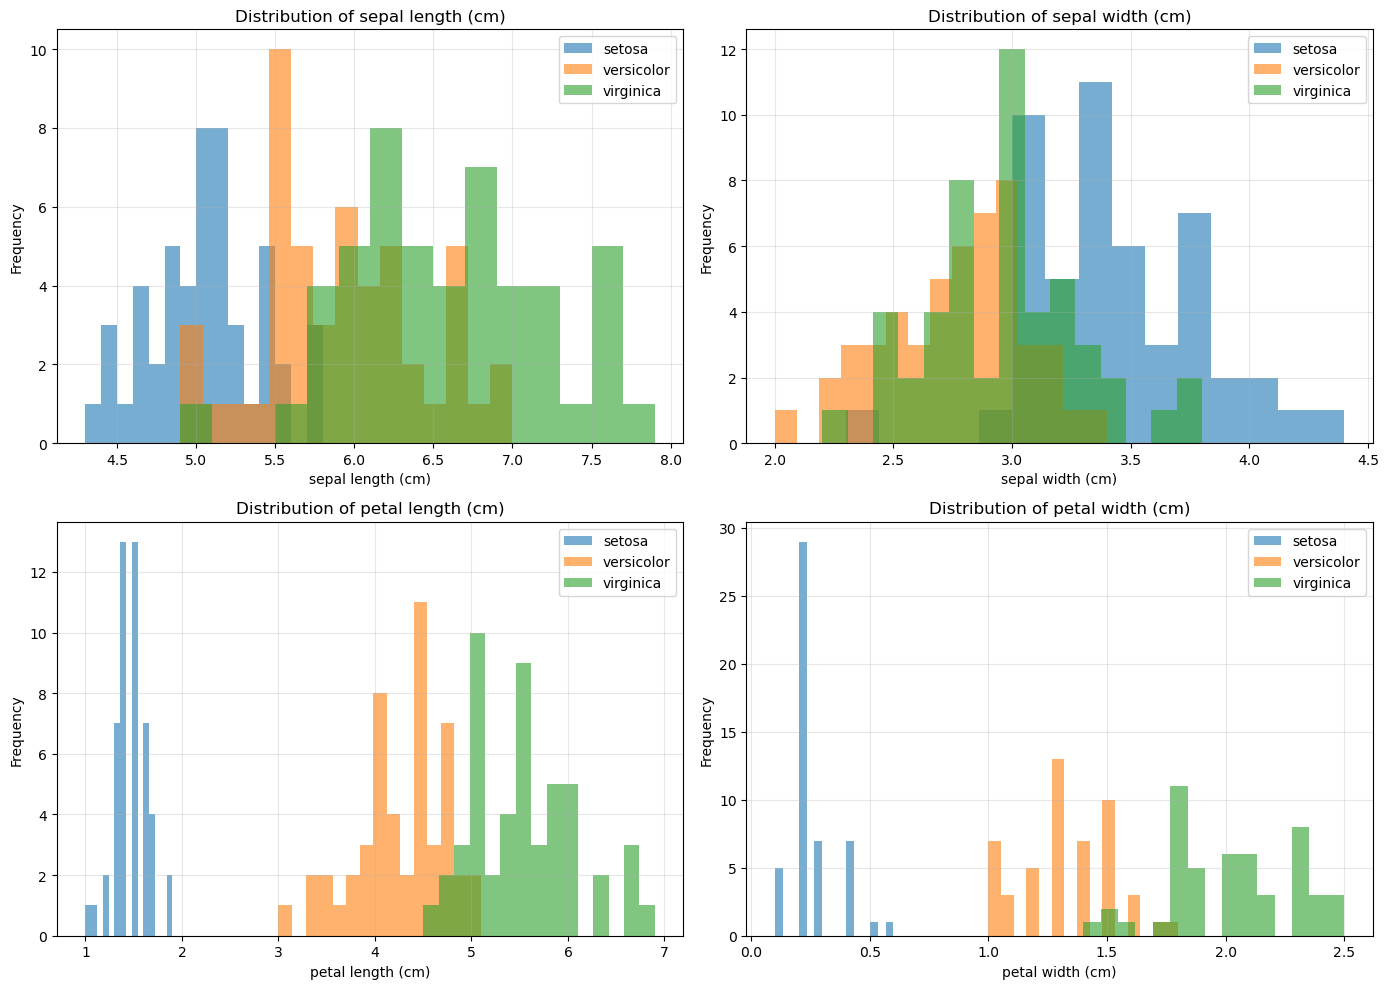

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, feature in enumerate(iris.feature_names):
    ax = axes[idx // 2, idx % 2]
    for species_idx, species_name in enumerate(iris.target_names):
        data = df[df['species'] == species_name][feature]
        ax.hist(data, alpha=0.6, label=species_name, bins=15)
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    ax.set_title(f'Distribution of {feature}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"\nTraining class distribution: {np.bincount(y_train)}")
print(f"Test class distribution: {np.bincount(y_test)}")

Training set size: (105, 4)
Test set size: (45, 4)

Training class distribution: [35 35 35]
Test class distribution: [15 15 15]


Part (i): Step-by-Step Implementation of Gaussian Naïve Bayes

In [31]:
class GaussianNaiveBayes:
    def __init__(self):
        self.classes = None
        self.mean = {}
        self.var = {}
        self.priors = {}
    
    def fit(self, X, y):
        self.classes = np.unique(y)
        n_samples = X.shape[0]
        
        for c in self.classes:
            X_c = X[y == c]
            self.mean[c] = np.mean(X_c, axis=0)
            self.var[c] = np.var(X_c, axis=0)
            self.priors[c] = X_c.shape[0] / n_samples
        
        return self
    
    def gaussian_probability(self, x, mean, var):
        eps = 1e-9
        coeff = 1.0 / np.sqrt(2.0 * np.pi * var + eps)
        exponent = np.exp(-((x - mean) ** 2) / (2 * var + eps))
        return coeff * exponent
    
    def predict_sample(self, x):
        posteriors = {}
        
        for c in self.classes:
            prior = np.log(self.priors[c])
            likelihood = np.sum(np.log(self.gaussian_probability(x, self.mean[c], self.var[c])))
            posteriors[c] = prior + likelihood
        
        return max(posteriors, key=posteriors.get)
    
    def predict(self, X):
        predictions = [self.predict_sample(x) for x in X]
        return np.array(predictions)
    
    def score(self, X, y):
        predictions = self.predict(X)
        return np.mean(predictions == y)

In [32]:
gnb_custom = GaussianNaiveBayes()
gnb_custom.fit(X_train, y_train)

y_pred_custom = gnb_custom.predict(X_test)

print("Step-by-Step Implementation Results:")
print("="*60)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred_custom):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_custom, target_names=iris.target_names))

Step-by-Step Implementation Results:

Accuracy: 0.9111

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



In [33]:
print("Learned Parameters (Step-by-Step Implementation):")
print("\nClass Priors:")
for c in gnb_custom.classes:
    print(f"  {iris.target_names[c]}: {gnb_custom.priors[c]:.4f}")

print("\nMean values per class:")
for c in gnb_custom.classes:
    print(f"\n{iris.target_names[c]}:")
    for i, feature in enumerate(iris.feature_names):
        print(f"  {feature}: {gnb_custom.mean[c][i]:.4f}")

print("\nVariance values per class:")
for c in gnb_custom.classes:
    print(f"\n{iris.target_names[c]}:")
    for i, feature in enumerate(iris.feature_names):
        print(f"  {feature}: {gnb_custom.var[c][i]:.4f}")

Learned Parameters (Step-by-Step Implementation):

Class Priors:
  setosa: 0.3333
  versicolor: 0.3333
  virginica: 0.3333

Mean values per class:

setosa:
  sepal length (cm): 4.9886
  sepal width (cm): 3.4257
  petal length (cm): 1.4857
  petal width (cm): 0.2400

versicolor:
  sepal length (cm): 5.9486
  sepal width (cm): 2.7314
  petal length (cm): 4.2371
  petal width (cm): 1.3086

virginica:
  sepal length (cm): 6.6829
  sepal width (cm): 3.0086
  petal length (cm): 5.6314
  petal width (cm): 2.0686

Variance values per class:

setosa:
  sepal length (cm): 0.1033
  sepal width (cm): 0.1739
  petal length (cm): 0.0229
  petal width (cm): 0.0093

versicolor:
  sepal length (cm): 0.2408
  sepal width (cm): 0.0856
  petal length (cm): 0.2115
  petal width (cm): 0.0356

virginica:
  sepal length (cm): 0.4248
  sepal width (cm): 0.1174
  petal length (cm): 0.3227
  petal width (cm): 0.0639


Part (ii): Built-in Function Implementation

In [34]:
gnb_sklearn = GaussianNB()
gnb_sklearn.fit(X_train, y_train)

y_pred_sklearn = gnb_sklearn.predict(X_test)

print("Built-in Function (sklearn) Results:")
print("="*60)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred_sklearn):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_sklearn, target_names=iris.target_names))

Built-in Function (sklearn) Results:

Accuracy: 0.9111

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



In [35]:
print("Learned Parameters (sklearn implementation):")
print("\nClass Priors:")
for i, c in enumerate(gnb_sklearn.classes_):
    print(f"  {iris.target_names[c]}: {gnb_sklearn.class_prior_[i]:.4f}")

print("\nMean values per class:")
for i, c in enumerate(gnb_sklearn.classes_):
    print(f"\n{iris.target_names[c]}:")
    for j, feature in enumerate(iris.feature_names):
        print(f"  {feature}: {gnb_sklearn.theta_[i][j]:.4f}")

print("\nVariance values per class:")
for i, c in enumerate(gnb_sklearn.classes_):
    print(f"\n{iris.target_names[c]}:")
    for j, feature in enumerate(iris.feature_names):
        print(f"  {feature}: {gnb_sklearn.var_[i][j]:.4f}")

Learned Parameters (sklearn implementation):

Class Priors:
  setosa: 0.3333
  versicolor: 0.3333
  virginica: 0.3333

Mean values per class:

setosa:
  sepal length (cm): 4.9886
  sepal width (cm): 3.4257
  petal length (cm): 1.4857
  petal width (cm): 0.2400

versicolor:
  sepal length (cm): 5.9486
  sepal width (cm): 2.7314
  petal length (cm): 4.2371
  petal width (cm): 1.3086

virginica:
  sepal length (cm): 6.6829
  sepal width (cm): 3.0086
  petal length (cm): 5.6314
  petal width (cm): 2.0686

Variance values per class:

setosa:
  sepal length (cm): 0.1033
  sepal width (cm): 0.1739
  petal length (cm): 0.0229
  petal width (cm): 0.0093

versicolor:
  sepal length (cm): 0.2408
  sepal width (cm): 0.0856
  petal length (cm): 0.2115
  petal width (cm): 0.0356

virginica:
  sepal length (cm): 0.4248
  sepal width (cm): 0.1174
  petal length (cm): 0.3227
  petal width (cm): 0.0639


### Comparison of Both Implementations

In [36]:
predictions_match = np.array_equal(y_pred_custom, y_pred_sklearn)

comparison = pd.DataFrame({
    'Implementation': ['Step-by-Step', 'sklearn Built-in'],
    'Accuracy': [accuracy_score(y_test, y_pred_custom), accuracy_score(y_test, y_pred_sklearn)]
})

print("\nComparison of Implementations:")
print(comparison.to_string(index=False))
print(f"\nPredictions Match: {predictions_match}")

print("\n\nPredictions on test set:")
print(f"Custom implementation: {y_pred_custom}")
print(f"sklearn implementation: {y_pred_sklearn}")
print(f"Actual values:          {y_test}")


Comparison of Implementations:
  Implementation  Accuracy
    Step-by-Step  0.911111
sklearn Built-in  0.911111

Predictions Match: True


Predictions on test set:
Custom implementation: [2 1 1 1 2 2 1 1 0 2 0 0 2 2 0 2 1 0 0 0 1 0 1 2 2 1 1 1 1 0 1 2 1 0 2 0 0
 0 0 2 1 0 1 2 1]
sklearn implementation: [2 1 1 1 2 2 1 1 0 2 0 0 2 2 0 2 1 0 0 0 1 0 1 2 2 1 1 1 1 0 1 2 1 0 2 0 0
 0 0 2 1 0 1 2 1]
Actual values:          [2 1 2 1 2 2 1 1 0 2 0 0 2 2 0 2 1 0 0 0 1 0 1 2 2 1 1 1 1 0 2 2 1 0 2 0 0
 0 0 1 1 0 2 2 1]


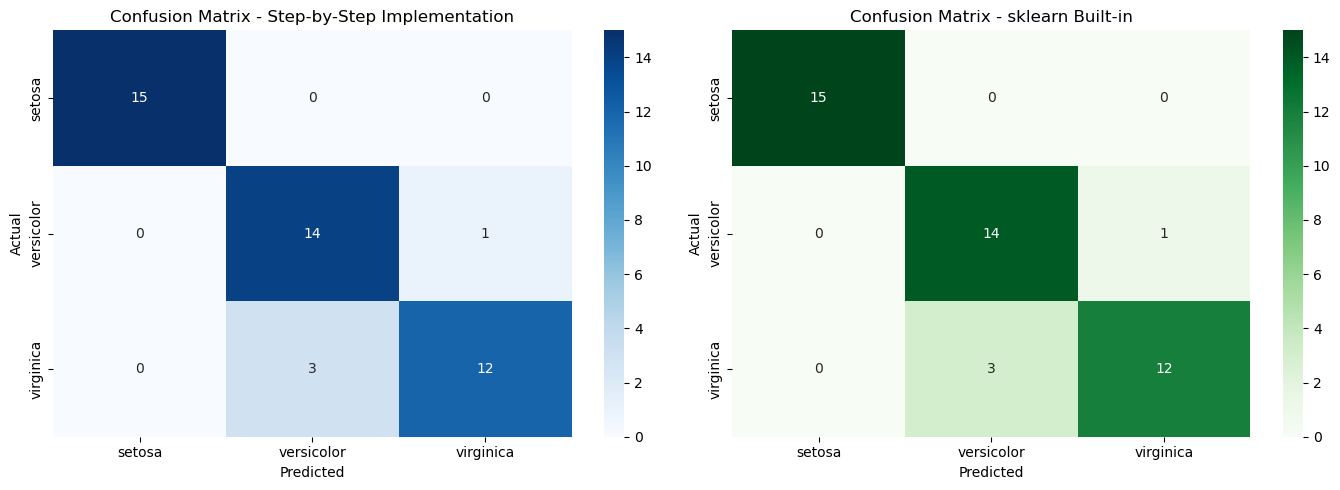

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_custom = confusion_matrix(y_test, y_pred_custom)
cm_sklearn = confusion_matrix(y_test, y_pred_sklearn)

sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Blues', xticklabels=iris.target_names, 
            yticklabels=iris.target_names, ax=axes[0])
axes[0].set_title('Confusion Matrix - Step-by-Step Implementation')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

sns.heatmap(cm_sklearn, annot=True, fmt='d', cmap='Greens', xticklabels=iris.target_names, 
            yticklabels=iris.target_names, ax=axes[1])
axes[1].set_title('Confusion Matrix - sklearn Built-in')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

In [38]:
y_prob_sklearn = gnb_sklearn.predict_proba(X_test)

print("Sample Predictions with Probabilities (sklearn):")
print("\nFirst 10 test samples:")
for i in range(min(10, len(X_test))):
    print(f"\nSample {i+1}:")
    print(f"  Actual: {iris.target_names[y_test[i]]}")
    print(f"  Predicted: {iris.target_names[y_pred_sklearn[i]]}")
    print(f"  Probabilities:")
    for j, prob in enumerate(y_prob_sklearn[i]):
        print(f"    {iris.target_names[j]}: {prob:.4f}")

Sample Predictions with Probabilities (sklearn):

First 10 test samples:

Sample 1:
  Actual: virginica
  Predicted: virginica
  Probabilities:
    setosa: 0.0000
    versicolor: 0.0000
    virginica: 1.0000

Sample 2:
  Actual: versicolor
  Predicted: versicolor
  Probabilities:
    setosa: 0.0000
    versicolor: 0.9955
    virginica: 0.0045

Sample 3:
  Actual: virginica
  Predicted: versicolor
  Probabilities:
    setosa: 0.0000
    versicolor: 0.8472
    virginica: 0.1528

Sample 4:
  Actual: versicolor
  Predicted: versicolor
  Probabilities:
    setosa: 0.0000
    versicolor: 0.6680
    virginica: 0.3320

Sample 5:
  Actual: virginica
  Predicted: virginica
  Probabilities:
    setosa: 0.0000
    versicolor: 0.1036
    virginica: 0.8964

Sample 6:
  Actual: virginica
  Predicted: virginica
  Probabilities:
    setosa: 0.0000
    versicolor: 0.0000
    virginica: 1.0000

Sample 7:
  Actual: versicolor
  Predicted: versicolor
  Probabilities:
    setosa: 0.0000
    versicolor: 1.00

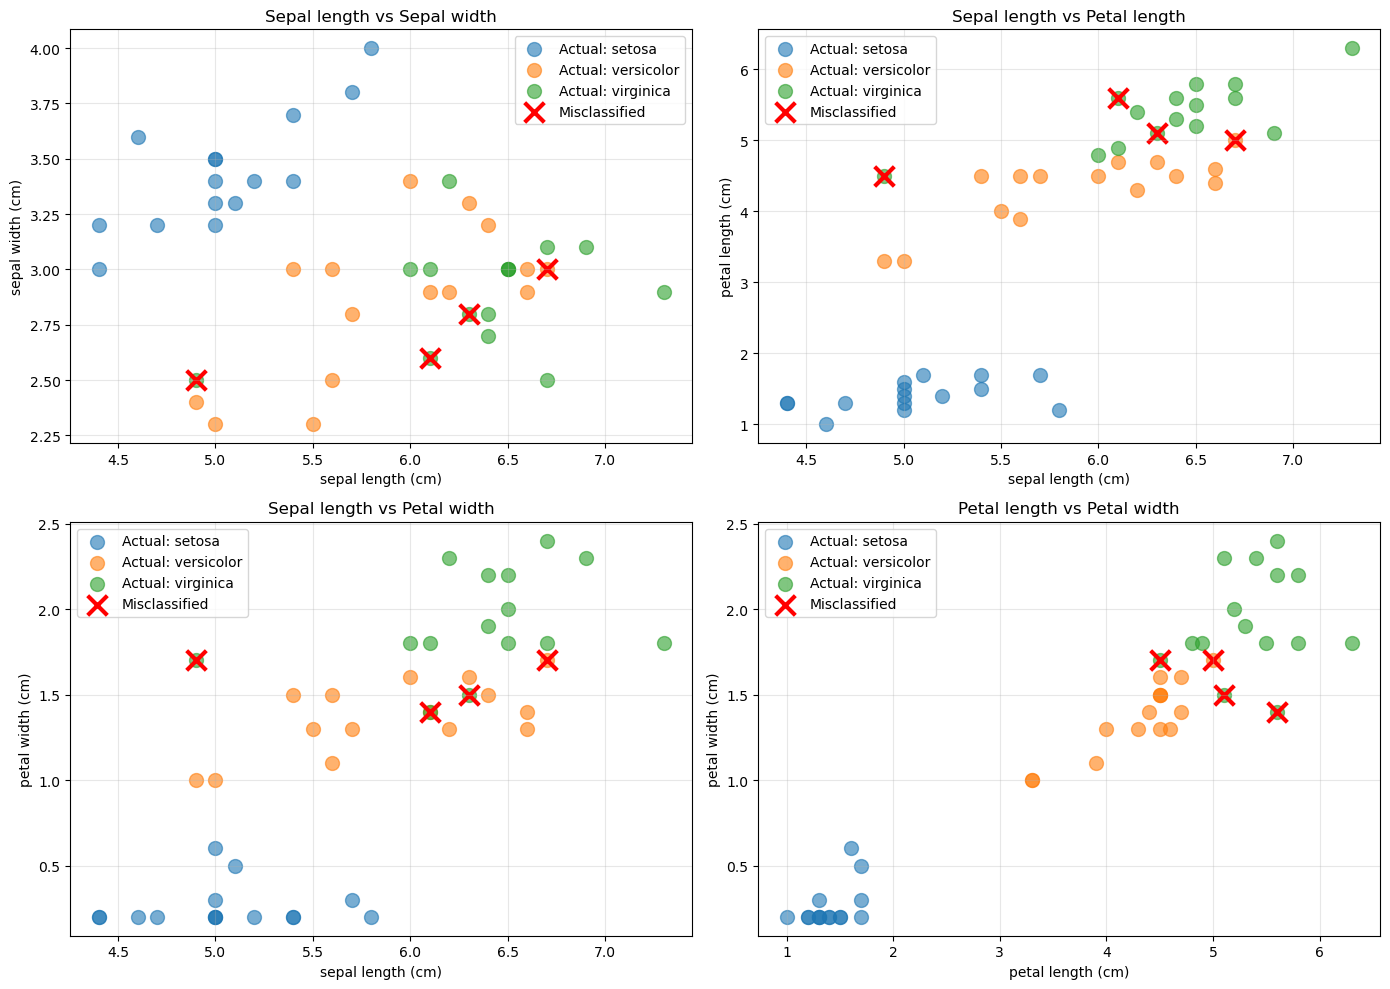

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

feature_pairs = [(0, 1), (0, 2), (0, 3), (2, 3)]
titles = ['Sepal length vs Sepal width', 'Sepal length vs Petal length', 
          'Sepal length vs Petal width', 'Petal length vs Petal width']

for idx, (f1, f2) in enumerate(feature_pairs):
    ax = axes[idx // 2, idx % 2]
    
    for species_idx, species_name in enumerate(iris.target_names):
        mask = y_test == species_idx
        ax.scatter(X_test[mask, f1], X_test[mask, f2], 
                  label=f'Actual: {species_name}', alpha=0.6, s=100)
    
    misclassified = y_test != y_pred_sklearn
    if np.any(misclassified):
        ax.scatter(X_test[misclassified, f1], X_test[misclassified, f2], 
                  marker='x', s=200, c='red', linewidths=3, 
                  label='Misclassified')
    
    ax.set_xlabel(iris.feature_names[f1])
    ax.set_ylabel(iris.feature_names[f2])
    ax.set_title(titles[idx])
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Q2
Explore about GridSearchCV toot in scikit-learn. This is a tool that is
often used for tuning hyperparameters of machine learning models. Use
this tool to find the best value of K for K-NN Classifier using any dataset

In [40]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train_scaled.shape}")
print(f"Test set: {X_test_scaled.shape}")

Training set: (105, 4)
Test set: (45, 4)


In [42]:
params = {
    'n_neighbors': list(range(1, 31)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

knn = KNeighborsClassifier()
grid = GridSearchCV(knn, params, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

print("Finding best parameters...")
grid.fit(X_train_scaled, y_train)
print("Done!")

Finding best parameters...
Fitting 5 folds for each of 180 candidates, totalling 900 fits
Done!
Done!


In [43]:
print("Best Parameters:")
print("="*60)
for param, value in grid.best_params_.items():
    print(f"{param}: {value}")

print(f"\nCV Score: {grid.best_score_:.4f}")
print(f"Best K: {grid.best_params_['n_neighbors']}")

Best Parameters:
metric: euclidean
n_neighbors: 3
weights: uniform

CV Score: 0.9429
Best K: 3


In [44]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test_scaled)

print("Test Results:")
print("="*60)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Test Results:
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [45]:
results = pd.DataFrame(grid.cv_results_)
top_10 = results.nsmallest(10, 'rank_test_score')[
    ['param_n_neighbors', 'param_weights', 'param_metric', 'mean_test_score', 'std_test_score', 'rank_test_score']
]

print("\nTop 10 combinations:")
print(top_10.to_string(index=False))


Top 10 combinations:
param_n_neighbors param_weights param_metric  mean_test_score  std_test_score  rank_test_score
                3       uniform    euclidean         0.942857        0.046657                1
                3      distance    euclidean         0.942857        0.046657                1
                5      distance    euclidean         0.942857        0.046657                1
               11      distance    euclidean         0.942857        0.035635                1
               12      distance    euclidean         0.942857        0.035635                1
               13      distance    euclidean         0.942857        0.035635                1
                7       uniform    manhattan         0.942857        0.035635                1
                3       uniform    minkowski         0.942857        0.046657                1
                3      distance    minkowski         0.942857        0.046657                1
                5      dista

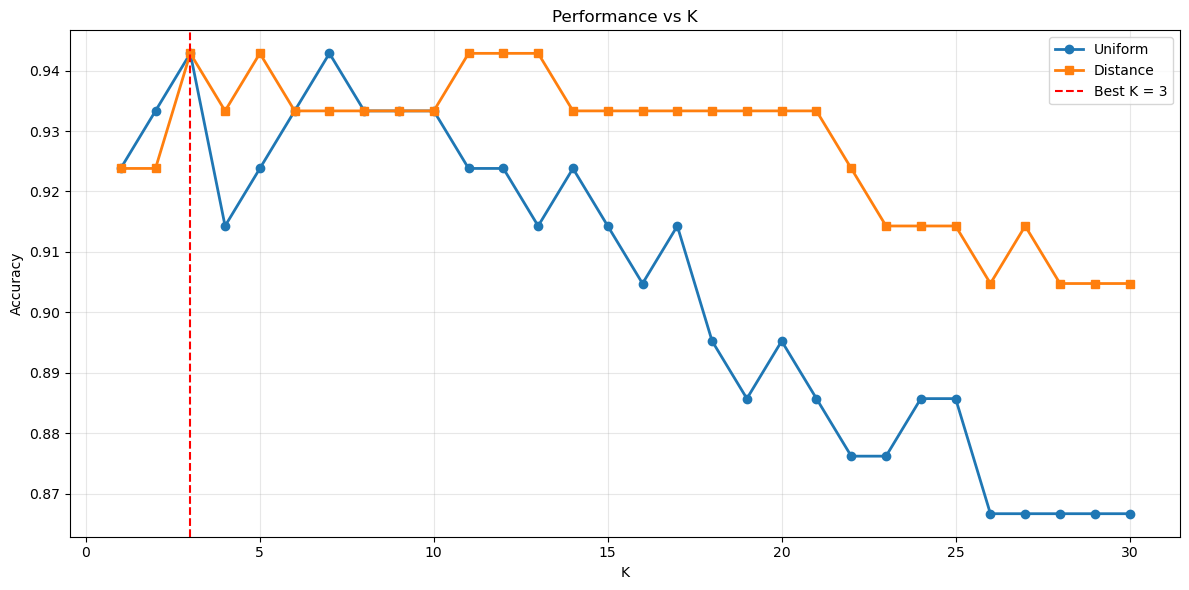

In [46]:
k_vals = list(range(1, 31))
uniform = []
distance = []

for k in k_vals:
    u = (results['param_n_neighbors'] == k) & (results['param_weights'] == 'uniform')
    d = (results['param_n_neighbors'] == k) & (results['param_weights'] == 'distance')
    
    if u.any():
        uniform.append(results[u]['mean_test_score'].max())
    if d.any():
        distance.append(results[d]['mean_test_score'].max())

plt.figure(figsize=(12, 6))
plt.plot(k_vals, uniform, marker='o', label='Uniform', linewidth=2)
plt.plot(k_vals, distance, marker='s', label='Distance', linewidth=2)
plt.axvline(grid.best_params_['n_neighbors'], color='red', linestyle='--', 
            label=f'Best K = {grid.best_params_["n_neighbors"]}')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.title('Performance vs K')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

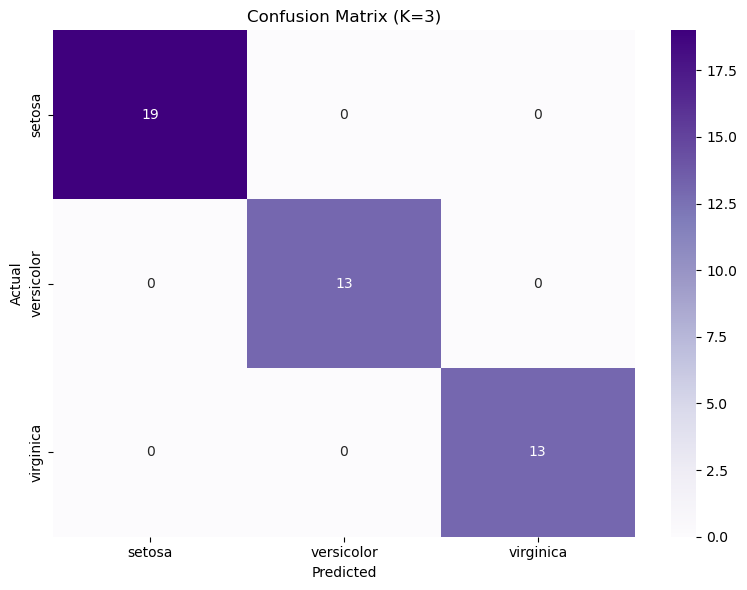

In [47]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title(f'Confusion Matrix (K={grid.best_params_["n_neighbors"]})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

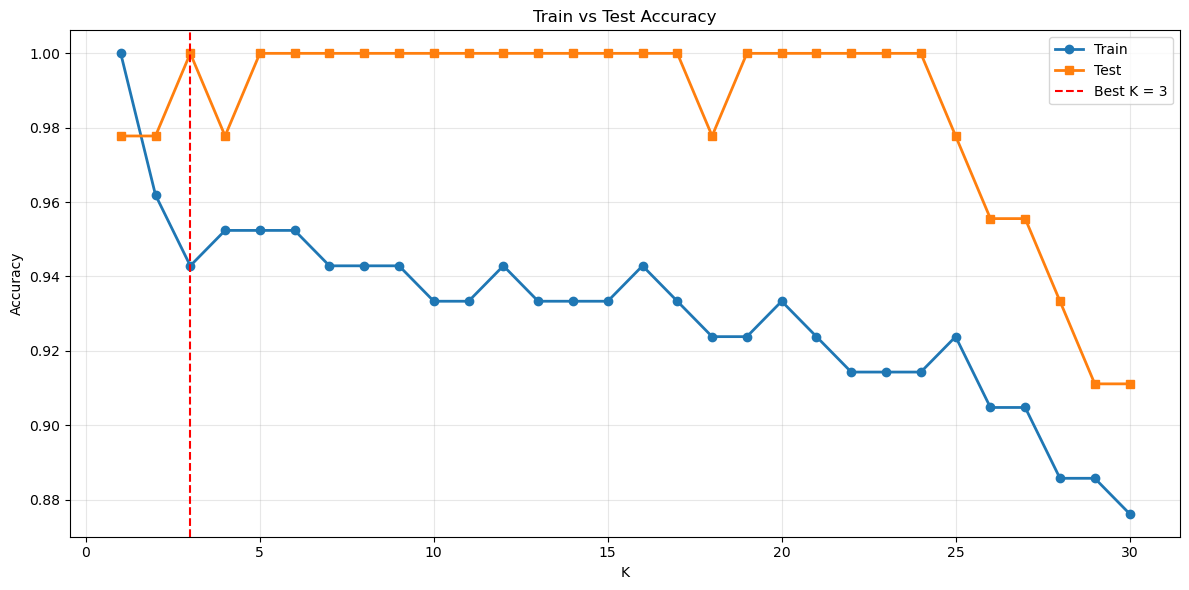

In [48]:
k_range = list(range(1, 31))
train_acc = []
test_acc = []

for k in k_range:
    model = KNeighborsClassifier(n_neighbors=k, weights=grid.best_params_['weights'], 
                                  metric=grid.best_params_['metric'])
    model.fit(X_train_scaled, y_train)
    train_acc.append(model.score(X_train_scaled, y_train))
    test_acc.append(model.score(X_test_scaled, y_test))

plt.figure(figsize=(12, 6))
plt.plot(k_range, train_acc, marker='o', label='Train', linewidth=2)
plt.plot(k_range, test_acc, marker='s', label='Test', linewidth=2)
plt.axvline(grid.best_params_['n_neighbors'], color='red', linestyle='--', 
            label=f'Best K = {grid.best_params_["n_neighbors"]}')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


By metric:
                  mean       max       min
param_metric                              
euclidean     0.907937  0.942857  0.866667
manhattan     0.912698  0.942857  0.857143
minkowski     0.907937  0.942857  0.866667

By weights:
                   mean       max       min
param_weights                              
distance       0.919683  0.942857  0.876190
uniform        0.899365  0.942857  0.857143


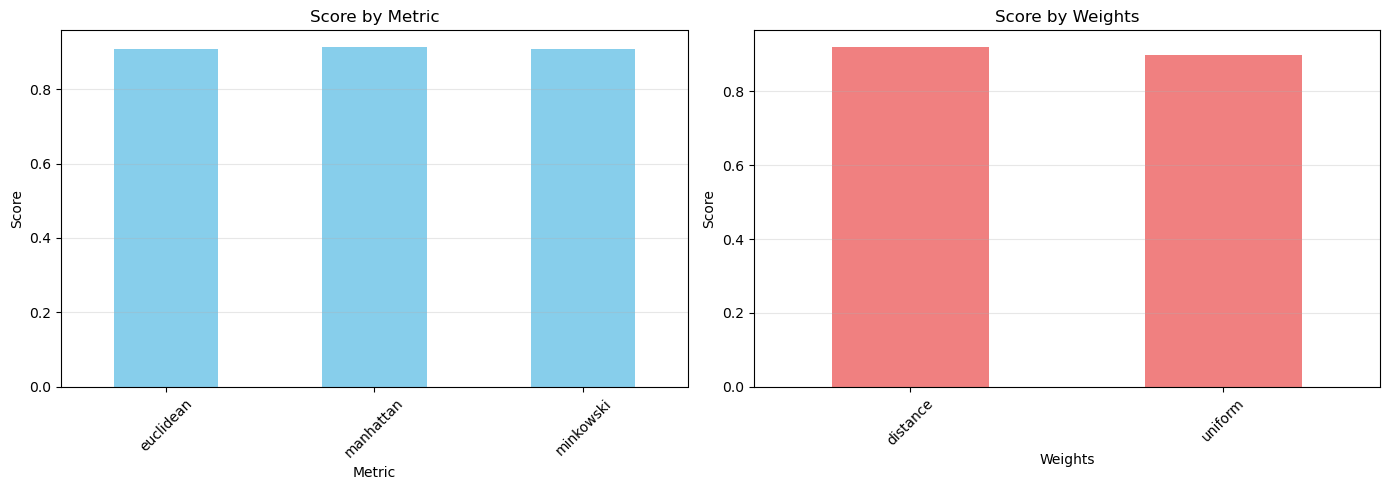

In [49]:
by_metric = results.groupby('param_metric')['mean_test_score'].agg(['mean', 'max', 'min'])
by_weights = results.groupby('param_weights')['mean_test_score'].agg(['mean', 'max', 'min'])

print("\nBy metric:")
print(by_metric)
print("\nBy weights:")
print(by_weights)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

by_metric['mean'].plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Score by Metric')
axes[0].set_ylabel('Score')
axes[0].set_xlabel('Metric')
axes[0].grid(alpha=0.3, axis='y')
axes[0].tick_params(axis='x', rotation=45)

by_weights['mean'].plot(kind='bar', ax=axes[1], color='lightcoral')
axes[1].set_title('Score by Weights')
axes[1].set_ylabel('Score')
axes[1].set_xlabel('Weights')
axes[1].grid(alpha=0.3, axis='y')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()